# Framework Tests

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

C:\PythonProjects\python_beginners_course-main\ML_Workshop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Creating and Manipulating Tensor objects

In [2]:
from engine import Tensor

In [3]:
print('TENSOR OBJECT ATTRIBUTES:')
x = Tensor(np.arange(16).reshape(4, 4))
print('x =', x)
print('x.data:', x.data)
print('x.requires_grad:', x.requires_grad)
print('x.shape:', x.shape)
print('len(x):', len(x))
print('element [0,0]:', x[0, 0])
print('x.grad:', x.grad)

TENSOR OBJECT ATTRIBUTES:
x = Tensor(data=[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]])
x.data: [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]]
x.requires_grad: False
x.shape: (4, 4)
len(x): 4
element [0,0]: Tensor(data=0.0)
x.grad: [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [4]:
print('\nTENSOR ARITHMETICS (SCALARS):')
a = Tensor([3])
b = 2
print('a:', a, 'b:', b)
print('a+b:', a+b)
print('b+a:', b+a)
print('a*b:', a*b)
print('b*a:', b*a)
print('a-b:', a-b)
print('b-a:', b-a)
print('a**b:', a**b)
print('a/b:', a/b)
print('log(a):', a.log())
print('exp(a):', a.exp())


TENSOR ARITHMETICS (SCALARS):
a: Tensor(data=[3.]) b: 2
a+b: Tensor(data=[5.])
b+a: Tensor(data=[5.])
a*b: Tensor(data=[6.])
b*a: Tensor(data=[6.])
a-b: Tensor(data=[1.])
b-a: Tensor(data=[-1.])
a**b: Tensor(data=[9.])
a/b: Tensor(data=[1.5])
log(a): Tensor(data=[1.0986123])
exp(a): Tensor(data=[20.085537])


In [5]:
print('TENSOR ARITHMETICS (MATRICES):')
a = Tensor([[1, 2, 3], 
            [4, 5, 6], 
            [7, 8, 9]])
b = Tensor([[1], [1], [1]])
print('a.shape:', a.shape)
print('b.shape:', b.shape)
print('a:', a, 'b:', b)
print('a+b:', a+b)
print('b+a:', b+a)
print('a*b:', a*b)
print('b*a:', b*a)
print('a-b:', a-b)
print('b-a:', b-a)
print('a/b:', a/b)
print('log(a):', a.log())
print('mean(a):', a.mean())
print('max(a):', a.max())
print('sum(a):', a.sum())
print('a @ b:', a @ b)
print('relu(a):', a.relu())
print('tanh(a):', a.tanh())

TENSOR ARITHMETICS (MATRICES):
a.shape: (3, 3)
b.shape: (3, 1)
a: Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]) b: Tensor(data=[[1.]
 [1.]
 [1.]])
a+b: Tensor(data=[[ 2.  3.  4.]
 [ 5.  6.  7.]
 [ 8.  9. 10.]])
b+a: Tensor(data=[[ 2.  3.  4.]
 [ 5.  6.  7.]
 [ 8.  9. 10.]])
a*b: Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]])
b*a: Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]])
a-b: Tensor(data=[[0. 1. 2.]
 [3. 4. 5.]
 [6. 7. 8.]])
b-a: Tensor(data=[[ 0. -1. -2.]
 [-3. -4. -5.]
 [-6. -7. -8.]])
a/b: Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]])
log(a): Tensor(data=[[0.        0.6931472 1.0986123]
 [1.3862944 1.609438  1.7917595]
 [1.9459102 2.0794415 2.1972246]])
mean(a): Tensor(data=5.0)
max(a): Tensor(data=9.0)
sum(a): Tensor(data=45.0)
a @ b: Tensor(data=[[ 6.]
 [15.]
 [24.]])
relu(a): Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]])
tanh(a): Tensor(data=[[0.7615942  0.9640276  0.9950548 ]
 [0.9993293  0.9999092  0.9999877 ]
 [0.99999833 0.99999976 1.        ]])


## Testing API elements

In [6]:
from layers import Linear, BatchNorm1d, Dropout
from activations import ReLU, Tanh
from models import Sequential

### 1. Linear

In [7]:
linear = Linear(4, 8) # arbitrary values
linear

Linear(in_features=4, out_features=8, bias=True)

In [8]:
# Checking the attributes
linear.w.shape, linear.b.shape

((4, 8), (8,))

In [9]:
linear.w[0]

Tensor(data=[ 0.82445896  0.74353725 -0.32677284 -0.1588608   0.8384253   0.8007757
  0.30248132  0.10110898], requires_grad=True)

In [10]:
linear.parameters()

[Tensor(data=[[ 0.82445896  0.74353725 -0.32677284 -0.1588608   0.8384253   0.8007757
    0.30248132  0.10110898]
  [ 0.01304732 -1.3157303  -0.31275755  1.4914522   0.04699207  1.240547
    0.16930677 -1.4043161 ]
  [-0.66337645 -0.09907151  0.21179327 -0.36239582  0.18066096  1.255773
   -0.3188006   0.52272195]
  [ 0.95545584 -0.5279418   1.6366924  -0.11651423 -1.2148148  -0.52526367
   -0.7648568  -0.43652362]], requires_grad=True),
 Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0.], requires_grad=True)]

In [11]:
# __call__ test
x = Tensor(np.random.randn(4).reshape(1, 4))
y = linear(x)
y

Tensor(data=[[-0.97331965 -0.5312847   2.3592114  -1.4878666  -1.316312    1.0411761
  -1.6631882   1.285473  ]], requires_grad=True)

### 2. BatchNorm1d

In [12]:
bn = BatchNorm1d(8)
bn

BatchNorm1d(features=8)

In [13]:
bn.parameters()

[Tensor(data=[1. 1. 1. 1. 1. 1. 1. 1.], requires_grad=True),
 Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0.], requires_grad=True)]

In [14]:
bn = BatchNorm1d(8)
bn.train()
y = bn(y)
y

Tensor(data=[[0. 0. 0. 0. 0. 0. 0. 0.]], requires_grad=True)

### 3. Dropout

In [15]:
dropout = Dropout(keep_prob=0.5)
dropout

Dropout(keep_prob=0.5)

In [16]:
x = Tensor(np.random.randn(9).reshape(3, 3))
x

Tensor(data=[[ 1.3343898   0.980575    1.322495  ]
 [ 1.0765014   0.37552512  1.6352257 ]
 [-0.1329505  -1.1985569   0.81859374]])

In [17]:
dropout.train()
y = dropout(x)
y

Tensor(data=[[ 2.6687796  0.         2.64499  ]
 [ 0.         0.         3.2704513]
 [-0.        -0.         0.       ]])

### 4. Relu & Tanh

In [18]:
x = Tensor(np.arange(-10, 10))
x

Tensor(data=[-10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.
   4.   5.   6.   7.   8.   9.])

In [19]:
out = ReLU()(x)
out

Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 5. 6. 7. 8. 9.])

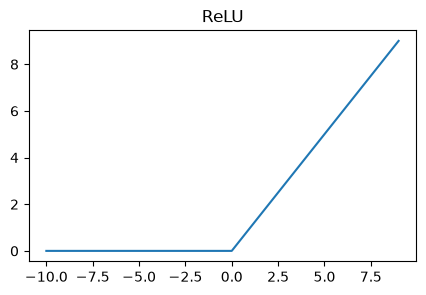

In [20]:
plt.figure(figsize=(5, 3))
plt.plot(x.data, out.data)
plt.title('ReLU');

In [21]:
out = Tanh()(x)
out

Tensor(data=[-1.         -1.         -0.99999976 -0.99999833 -0.99998766 -0.99990916
 -0.9993293  -0.9950548  -0.9640276  -0.7615941   0.          0.7615942
  0.9640276   0.9950548   0.9993293   0.9999092   0.9999877   0.99999833
  0.99999976  1.        ])

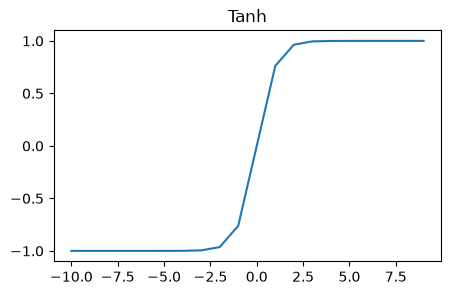

In [22]:
plt.figure(figsize=(5, 3))
plt.plot(x.data, out.data)
plt.title('Tanh');

### 5. Sequential

In [23]:
model = Sequential(
    Linear(3, 16), BatchNorm1d(16), ReLU(),
    Dropout(keep_prob=0.9),
    Linear(16, 8)
)
model

Sequential((Linear(in_features=3, out_features=16, bias=True), BatchNorm1d(features=16), ReLU(), Dropout(keep_prob=0.9), Linear(in_features=16, out_features=8, bias=True)))

In [24]:
x = Tensor(np.random.randn(9).reshape(3, 3))
x

Tensor(data=[[ 0.83525836  0.31983942 -0.6491976 ]
 [ 2.2031374  -0.424595   -2.2432344 ]
 [ 1.0374696   0.74149287  2.5369923 ]])

In [25]:
model(x)

Tensor(data=[[ 0.8722102  -0.24823268 -0.03920459 -0.3227386   1.369949   -0.6515863
  -0.03961114 -0.68850017]
 [ 2.5500636  -1.1014919  -0.75111574 -1.4843612   4.5137105  -1.0188468
   0.8521985  -1.853206  ]
 [ 0.564609   -1.6117017   0.21582362  2.051968    1.717938   -1.9323639
  -0.07446443 -2.4528525 ]], requires_grad=True)

In [26]:
model.parameters()

[Tensor(data=[[-1.3539076  -0.70902693 -0.28437915  0.7929881   0.3549447  -1.3191913
   -0.40468153 -0.54192805  1.1785482  -0.8027598   1.2098348  -1.6081102
    1.3870499  -0.80408657 -1.3361571   1.6948737 ]
  [ 0.53082436  0.9278408   0.5341382  -0.7761261  -0.82568485 -1.2708055
   -0.15824926  0.1666095   0.475726    0.67098254 -0.8684354  -1.300416
    0.09950384  0.24558793 -0.76644194 -0.05910384]
  [-0.61047727 -0.04105776  1.0029786   0.39376697 -0.31796417 -0.34553784
    0.37328935  0.3962512   0.61692816  1.4817114   0.07968189  0.27143705
   -0.17374231 -0.62921715 -1.0180228  -1.2555971 ]], requires_grad=True),
 Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], requires_grad=True),
 Tensor(data=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.], requires_grad=True),
 Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], requires_grad=True),
 Tensor(data=[[-7.5152552e-01  4.2776781e-01 -1.3490927e-01 -1.4985940e-01
   -2.1695982e-01 -2.8939299e-02 -

## Training MLP

In [27]:
from optimizers import Adam
from functions import cross_entropy

In [28]:
# train data
x_train = Tensor([
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
])

# train targets
y_train = np.array([1, 0, 0, 1], dtype=np.int32)

# test data
x_test = Tensor([
    [2.5,  2.5, -0.8],   
    [3.2, -0.7,  0.3],  
    [0.7,  1.2,  0.8],  
    [1.2,  0.8, -0.9], 
    [2.2,  3.1, -1.2],
    [2.8, -1.2,  0.7], 
])

# test targets
y_test = np.array([1, 0, 0, 1, 1, 0], dtype=np.int32)


model = Sequential(
    Linear(x_train.shape[1], 16), BatchNorm1d(16), ReLU(),
    Dropout(keep_prob=0.9),
    Linear(16, 8), BatchNorm1d(8), ReLU(),
    Linear(8, 2)
)

optimizer = Adam(parameters=model.parameters(), lr=0.001)

epochs = 1000
loop = tqdm(range(epochs), total=epochs, desc='Training')
train_losses = []
test_losses = []

for epoch in loop:
    # ------- TRAINING --------
    model.train()
    
    # Forward pass
    y_pred_logits = model(x_train)

    # Loss
    loss = cross_entropy(y_pred_logits, y_train)
    train_losses.append(loss.data)

    # Zero grad
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update
    optimizer.update()

    # ------ EVALUATING ------
    model.evaluate()

    # Forward pass
    y_pred_logits = model(x_test)

    # Loss
    loss = cross_entropy(y_pred_logits, y_test)
    test_losses.append(loss.data)
    
    # Track test loss
    loop.set_postfix(test_loss=f'{loss.data}')

Training: 100%|██████████| 1000/1000 [00:02<00:00, 408.49it/s, test_loss=0.009703462943434715]


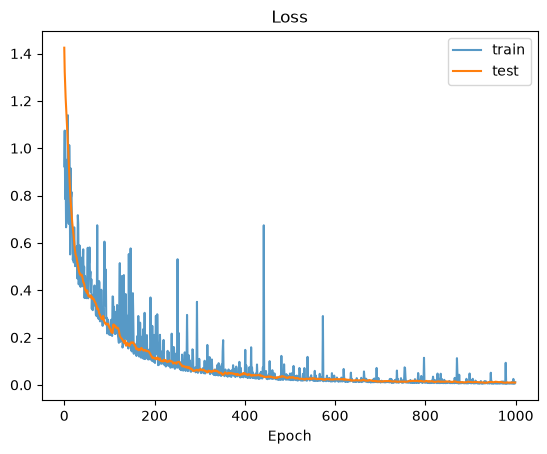

In [29]:
plt.plot(train_losses, alpha=0.75, label='train')
plt.plot(test_losses, label='test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend();

### Training using `.run_autotraining()`

In [30]:
# SETUP

x_train = Tensor([
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
])

y_train = np.array([1, 0, 0, 1], dtype=np.int32)

x_test = Tensor([
    [2.5,  2.5, -0.8],   
    [3.2, -0.7,  0.3],  
    [0.7,  1.2,  0.8],  
    [1.2,  0.8, -0.9], 
    [2.2,  3.1, -1.2],
    [2.8, -1.2,  0.7], 
])

y_test = np.array([1, 0, 0, 1, 1, 0], dtype=np.int32)


model = Sequential(
    Linear(x_train.shape[1], 16), BatchNorm1d(16), ReLU(),
    Dropout(keep_prob=0.9),
    Linear(16, 8), BatchNorm1d(8), ReLU(),
    Linear(8, 2)
)

optimizer = Adam(parameters=model.parameters(), lr=0.001)
epochs = 1000

Training: 100%|██████████| 1000/1000 [00:02<00:00, 375.70it/s, test_loss=0.013808042742311954]


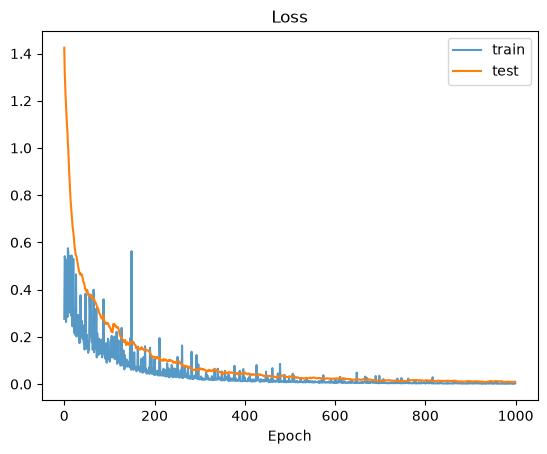

In [31]:
# TRAIN & PLOT
train_losses, val_losses = model.run_autotraining(epochs, optimizer, cross_entropy, x_train, y_train, x_test, y_test)

plt.plot(train_losses, alpha=0.75, label='train')
plt.plot(test_losses, label='test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend();

## Comparison with PyTorch on MNIST dataset

In [32]:
from timeit import default_timer as timer

### 1. Custom framework

In [33]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
x = mnist.data / 255.0
y = mnist.target.astype(np.int64)

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42)

x_train = Tensor(x_train)
x_val = Tensor(x_val)

np.random.seed(42)
model = Sequential(
    Linear(x_train.shape[1], 16), BatchNorm1d(16), ReLU(),
    Linear(16, 8), BatchNorm1d(8), ReLU(),
    Linear(8, 10)
)

optimizer = Adam(parameters=model.parameters(), lr=0.001)
epochs = 1000

start = timer()
train_losses, val_losses = model.run_autotraining(epochs, optimizer, cross_entropy, x_train, y_train, x_val, y_val)
end = timer()
training_time_custom = end - start

Training: 100%|██████████| 1000/1000 [02:52<00:00,  5.80it/s, test_loss=0.2323896586894989]


### 2. PyTorch equivalent

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

x = mnist.data / 255.0
y = mnist.target.astype(np.int64)

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42)

x_train = torch.tensor(x_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)  
y_val = torch.tensor(y_val, dtype=torch.long)

torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(x_train.shape[1], 16), nn.BatchNorm1d(16), nn.ReLU(),
    nn.Linear(16, 8), nn.BatchNorm1d(8), nn.ReLU(),
    nn.Linear(8, 10)
)

train_losses_torch = []
val_losses_torch = []
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)
epochs = 1000

loop = tqdm(range(epochs), total=epochs, desc='Training PyTorch equivalent')
start = timer()
for epoch in loop:
    model.train()
    y_pred_logits = model(x_train)
    loss = F.cross_entropy(y_pred_logits, y_train)
    train_losses_torch.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_logits = model(x_val)
        loss = F.cross_entropy(y_pred_logits, y_val)
        val_losses_torch.append(loss.item())
    
    loop.set_postfix(loss=f'{loss.item()}')

end = timer()
training_time_torch = end - start

Training PyTorch equivalent: 100%|██████████| 1000/1000 [01:06<00:00, 14.93it/s, loss=0.2692919373512268]


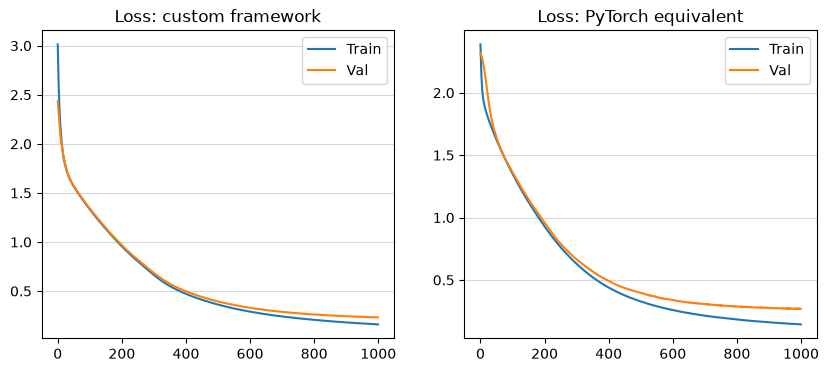

In [35]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss: custom framework')
plt.grid(axis='y', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses_torch, label='Train')
plt.plot(val_losses_torch, label='Val')
plt.title('Loss: PyTorch equivalent')
plt.grid(axis='y', alpha=0.5)
plt.legend()
plt.show()

In [38]:
print(f"Average of 10 last val loss values (custom framework): {np.mean(val_losses[-10:]):.4f}")
print(f"Average of 10 last val loss values (PyTorch): {np.mean(val_losses_torch[-10:]):.4f}")
print()
print(f"Training time (custom framework): {training_time_custom:.0f} sec")
print(f"Training time (PyTorch): {training_time_torch:.0f} sec")

Average of 10 last val loss values (custom framework): 0.2329
Average of 10 last val loss values (PyTorch): 0.2694

Training time (custom framework): 172 sec
Training time (PyTorch): 67 sec


As a result, both frameworks achieve similar validation loss of ~0.25

PyTorch ended up being much more efficient due to how thoroughly and professionally it is optimized. However, our framework showed slightly lower validation loss and a smaller gap between train and validation results, whereas PyTorch alternative showed some signs of mild overfitting.  